# Project 2 — Supervised Learning Pipeline

**Dataset:** Required Course Dataset  
**Target:** `OrderStatus` (5-class classification)

This notebook implements the Project 2 workflow: preprocessing, leakage-safe SMOTE, Logistic Regression, Random Forest, hyperparameter tuning, and evaluation using Precision, Recall, F1 and multiclass ROC-AUC.

**Important:** the supplied dataset does not contain a documented fraud label. Therefore, this notebook applies the requested supervised-learning pipeline to `OrderStatus`; it does not claim to be a validated fraud detector.

## 1. Imports and configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

RANDOM_STATE = 42
DATA_PATH = "Dataset for Data Analytics - Sheet1.csv"
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load and inspect the dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
display(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.dtypes)


Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.6200,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1000
1,ORD200001,2024-08-23,C75739,Phone,2,151.3500,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.6800,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.4000
3,ORD200003,2023-10-15,C33540,Chair,1,273.1900,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.1900
4,ORD200004,2025-05-08,C81840,Printer,4,626.0100,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.0400



Missing values:


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


Duplicate rows: 0


OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object

## 3. Initial numerical and categorical checks

In [4]:
display(df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].describe())

print("Invalid numerical values:")
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("ItemsInCart <= 0:", (df["ItemsInCart"] <= 0).sum())
print("TotalPrice <= 0:", (df["TotalPrice"] <= 0).sum())

for col in ["Product","PaymentMethod","OrderStatus","CouponCode","ReferralSource"]:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False))


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.0000,1200.0000,1200.0000,1200.0000
mean,2.9458,356.4128,5.4850,1053.9683
std,1.4076,197.1771,2.2820,819.8566
min,1.0000,11.3900,1.0000,11.3900
25%,2.0000,186.0625,4.0000,410.5200
50%,3.0000,364.2100,5.0000,823.6150
75%,4.0000,521.5700,7.0000,1578.4750
max,5.0000,699.9300,10.0000,3456.4000


Invalid numerical values:
Quantity <= 0: 0
UnitPrice <= 0: 0
ItemsInCart <= 0: 0
TotalPrice <= 0: 0

Product:


Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


PaymentMethod:


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

...

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


CouponCode:


CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64


ReferralSource:


ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

## 4. Target distribution

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

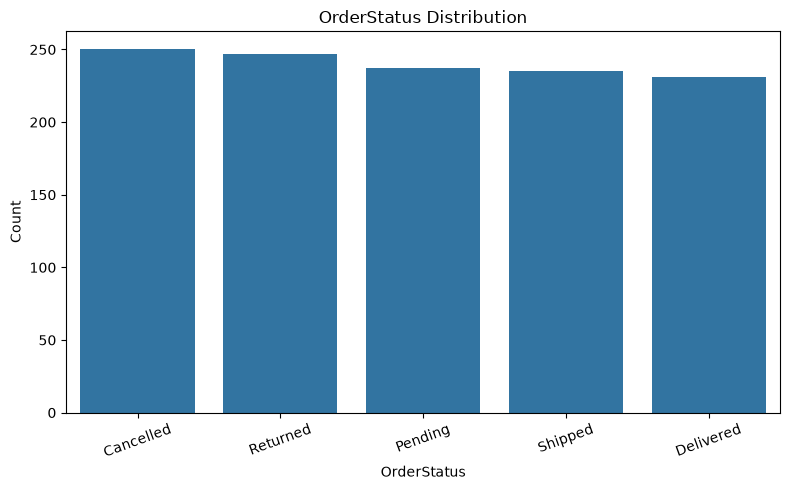

In [5]:
target_counts = df["OrderStatus"].value_counts()
display(target_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="OrderStatus", order=target_counts.index)
plt.title("OrderStatus Distribution")
plt.xlabel("OrderStatus")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Cleaning and feature engineering

Decisions from the data inspection:
- Remove `OrderID` and `TrackingNumber` as unique identifiers.
- Remove `CustomerID` because it is almost unique.
- Remove high-cardinality `ShippingAddress`.
- Convert `Date` into `Year`, `Month`, `Day`, and `DayOfWeek`.
- Fill missing `CouponCode` with `NoCoupon`.
- Remove `TotalPrice` because it is exactly `Quantity × UnitPrice`.
- Keep `OrderStatus` as the five-class target.

In [6]:
df_clean = df.copy()

df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["DayOfWeek"] = df_clean["Date"].dt.dayofweek

df_clean["CouponCode"] = df_clean["CouponCode"].fillna("NoCoupon")

calculated_total = df_clean["Quantity"] * df_clean["UnitPrice"]
print(
    "Rows where TotalPrice differs from Quantity × UnitPrice:",
    (np.abs(df_clean["TotalPrice"] - calculated_total) > 1e-9).sum()
)

df_clean = df_clean.drop(columns=[
    "OrderID", "Date", "CustomerID",
    "ShippingAddress", "TrackingNumber", "TotalPrice"
])

print("Cleaned shape:", df_clean.shape)
display(df_clean.head())


Rows where TotalPrice differs from Quantity × UnitPrice: 0
Cleaned shape: (1200, 12)


,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,Year,Month,Day,DayOfWeek
0,Monitor,5,570.6200,Debit Card,Shipped,7,SAVE10,Instagram,2023,1,4,2
1,Phone,2,151.3500,Online,Shipped,3,SAVE10,Referral,2024,8,23,4
2,Tablet,5,550.6800,Credit Card,Cancelled,8,FREESHIP,Email,2024,2,27,1
3,Chair,1,273.1900,Debit Card,Returned,5,SAVE10,Facebook,2023,10,15,6
4,Printer,4,626.0100,Online,Delivered,8,SAVE10,Email,2025,5,8,3


## 6. Prepare X/y and stratified train/test split

In [7]:
X = df_clean.drop(columns=["OrderStatus"])
y = df_clean["OrderStatus"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTraining classes:")
display(y_train.value_counts())
print("\nTesting classes:")
display(y_test.value_counts())


X_train: (960, 11)
X_test : (240, 11)

Training classes:


OrderStatus
Cancelled    200
Returned     197
Pending      190
Shipped      188
Delivered    185
Name: count, dtype: int64


Testing classes:


OrderStatus
Returned     50
Cancelled    50
Pending      47
Shipped      47
Delivered    46
Name: count, dtype: int64

## 7. Preprocessing pipelines

In [8]:
numerical_features = [
    "Quantity", "UnitPrice", "ItemsInCart",
    "Year", "Month", "Day", "DayOfWeek"
]
categorical_features = [
    "Product", "PaymentMethod",
    "CouponCode", "ReferralSource"
]

preprocessor_lr = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

preprocessor_rf = ColumnTransformer([
    ("num", "passthrough", numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


## 8. Logistic Regression + SMOTE baseline

In [9]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)

precision_lr = precision_score(y_test, y_pred_lr, average="weighted")
recall_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")
roc_auc_lr = roc_auc_score(y_test, y_prob_lr, multi_class="ovr", average="weighted")

print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")
print(classification_report(y_test, y_pred_lr))


Precision : 0.1988
Recall    : 0.2042
F1 Score  : 0.1977
ROC-AUC   : 0.5072
              precision    recall  f1-score   support

   Cancelled       0.20      0.14      0.16        50
   Delivered       0.24      0.33      0.28        46
     Pending       0.22      0.28      0.24        47
    Returned       0.17      0.16      0.16        50
     Shipped       0.17      0.13      0.15        47

    accuracy                           0.20       240
   macro avg       0.20      0.21      0.20       240
weighted avg       0.20      0.20      0.20       240



### Logistic Regression confusion matrix

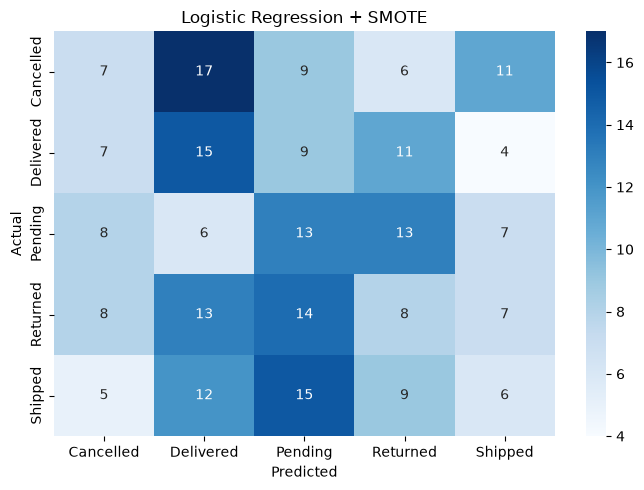

In [10]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7,5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=lr_pipeline.classes_,
            yticklabels=lr_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression + SMOTE")
plt.tight_layout()
plt.show()


## 9. Random Forest + SMOTE baseline

In [11]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)

precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")
roc_auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class="ovr", average="weighted")

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")
print(classification_report(y_test, y_pred_rf))


Precision : 0.1839
Recall    : 0.1792
F1 Score  : 0.1795
ROC-AUC   : 0.5027
              precision    recall  f1-score   support

   Cancelled       0.12      0.14      0.13        50
   Delivered       0.30      0.26      0.28        46
     Pending       0.18      0.23      0.21        47
    Returned       0.17      0.12      0.14        50
     Shipped       0.16      0.15      0.15        47

    accuracy                           0.18       240
   macro avg       0.19      0.18      0.18       240
weighted avg       0.18      0.18      0.18       240



### Random Forest confusion matrix

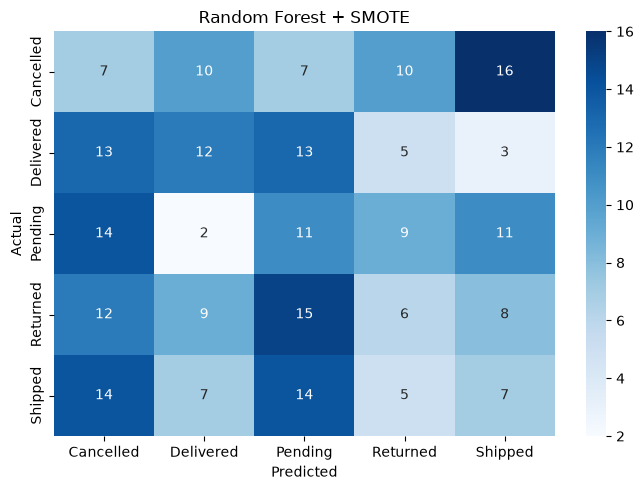

In [12]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_pipeline.classes_,
            yticklabels=rf_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest + SMOTE")
plt.tight_layout()
plt.show()


## 10. Hyperparameter tuning — Random Forest

In [13]:
rf_param_grid = {
    "smote__k_neighbors": [3, 5, 7],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    scoring="recall_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV weighted Recall:", rf_grid.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200, 'smote__k_neighbors': 5}
Best CV weighted Recall: 0.209375


### Tuned Random Forest evaluation

In [14]:
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)

precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned, average="weighted")
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned, average="weighted")
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average="weighted")
roc_auc_rf_tuned = roc_auc_score(
    y_test, y_prob_rf_tuned, multi_class="ovr", average="weighted"
)

print(f"Precision : {precision_rf_tuned:.4f}")
print(f"Recall    : {recall_rf_tuned:.4f}")
print(f"F1 Score  : {f1_rf_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_rf_tuned:.4f}")
print(classification_report(y_test, y_pred_rf_tuned))


Precision : 0.1754
Recall    : 0.1708
F1 Score  : 0.1694
ROC-AUC   : 0.5135
              precision    recall  f1-score   support

   Cancelled       0.14      0.14      0.14        50
   Delivered       0.20      0.20      0.20        46
     Pending       0.17      0.26      0.20        47
    Returned       0.24      0.16      0.19        50
     Shipped       0.12      0.11      0.11        47

    accuracy                           0.17       240
   macro avg       0.18      0.17      0.17       240
weighted avg       0.18      0.17      0.17       240



## 11. Hyperparameter tuning — Logistic Regression

In [15]:
lr_param_grid = {
    "smote__k_neighbors": [3, 5, 7],
    "classifier__C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    scoring="recall_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print("Best parameters:", lr_grid.best_params_)
print("Best CV weighted Recall:", lr_grid.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'classifier__C': 1, 'smote__k_neighbors': 3}
Best CV weighted Recall: 0.2208333333333333


### Tuned Logistic Regression evaluation

In [16]:
best_lr = lr_grid.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)

precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned, average="weighted")
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned, average="weighted")
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned, average="weighted")
roc_auc_lr_tuned = roc_auc_score(
    y_test, y_prob_lr_tuned, multi_class="ovr", average="weighted"
)

print(f"Precision : {precision_lr_tuned:.4f}")
print(f"Recall    : {recall_lr_tuned:.4f}")
print(f"F1 Score  : {f1_lr_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_lr_tuned:.4f}")
print(classification_report(y_test, y_pred_lr_tuned))


Precision : 0.2356
Recall    : 0.2375
F1 Score  : 0.2331
ROC-AUC   : 0.5131
              precision    recall  f1-score   support

   Cancelled       0.25      0.16      0.20        50
   Delivered       0.27      0.33      0.30        46
     Pending       0.25      0.32      0.28        47
    Returned       0.22      0.22      0.22        50
     Shipped       0.19      0.17      0.18        47

    accuracy                           0.24       240
   macro avg       0.24      0.24      0.23       240
weighted avg       0.24      0.24      0.23       240



### Tuned Logistic Regression confusion matrix

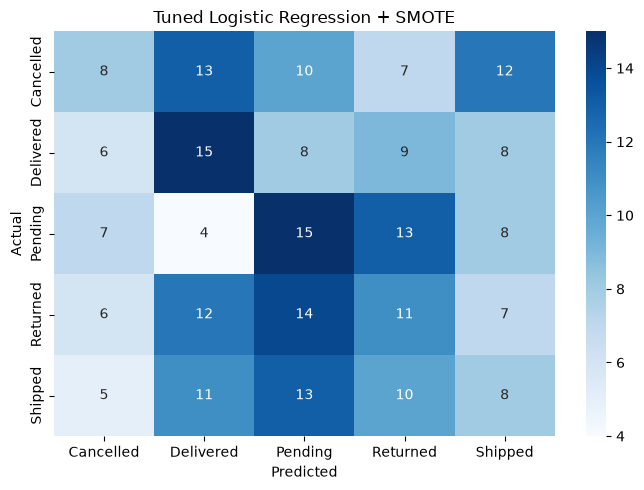

In [17]:
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)
plt.figure(figsize=(7,5))
sns.heatmap(cm_lr_tuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_lr.classes_,
            yticklabels=best_lr.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Logistic Regression + SMOTE")
plt.tight_layout()
plt.show()


## 12. Final results comparison

In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression + SMOTE",
        "Random Forest + SMOTE",
        "Tuned Random Forest + SMOTE",
        "Tuned Logistic Regression + SMOTE"
    ],
    "Precision": [0.1988, 0.1839, 0.1754, 0.2356],
    "Recall": [0.2042, 0.1792, 0.1708, 0.2375],
    "F1 Score": [0.1977, 0.1795, 0.1694, 0.2331],
    "ROC-AUC": [0.5072, 0.5027, 0.5135, 0.5131]
})
display(results)


,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression + SMOTE,0.1988,0.2042,0.1977,0.5072
1,Random Forest + SMOTE,0.1839,0.1792,0.1795,0.5027
2,Tuned Random Forest + SMOTE,0.1754,0.1708,0.1694,0.5135
3,Tuned Logistic Regression + SMOTE,0.2356,0.2375,0.2331,0.5131


## 13. Results discussion

The tuned Logistic Regression achieved Precision 0.2356, Recall 0.2375, F1 Score 0.2331 and ROC-AUC 0.5131 on the held-out test set. Its Precision, Recall and F1 were higher than the untuned Logistic Regression.

The tuned Random Forest achieved ROC-AUC 0.5135, slightly above the tuned Logistic Regression, but its Precision, Recall and F1 were lower.

The ROC-AUC values are close to 0.5 across all four experiments, and the confusion matrices show substantial overlap between the five classes. This indicates limited discriminative performance for the available `OrderStatus` features.